# Multiclass Classification Using a PyTorch Neural Network

This notebook uses the UCI OCR letter recognition dataset to classify letters A to Z with PyTorch and CUDA when available.

## Workflow

1. Load the OCR letter recognition dataset
2. Display the dataset with column names
3. Clean and inspect the data
4. Encode labels and scale features
5. Train a PyTorch classifier
6. Report accuracy, precision, recall, F1, and confusion matrix

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Libraries imported successfully.")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Libraries imported successfully.


In [2]:
# Load OCR dataset from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data"
column_names = ["letter"] + [f"feature_{i}" for i in range(1, 17)]
data = pd.read_csv(url, header=None, names=column_names)

print("Dataset shape:", data.shape)
print("Unique classes:", sorted(data["letter"].unique()))
print("Missing values:", data.isnull().sum().sum())
print("\nDataset preview with column names:")
print(data.head())

duplicate_count = data.duplicated().sum()
print("\nDuplicate rows:", duplicate_count)
if duplicate_count > 0:
    data = data.drop_duplicates().reset_index(drop=True)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data["letter"])
x = data.drop(columns=["letter"]).astype(float).values

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

majority_class = np.bincount(y_train).argmax()
baseline_accuracy = np.mean(y_test == majority_class)

print("\nTraining samples:", x_train.shape[0])
print("Test samples:", x_test.shape[0])
print("Features per sample:", x_train.shape[1])
print("Baseline accuracy (majority class):", round(baseline_accuracy, 4))

Dataset shape: (20000, 17)
Unique classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Missing values: 0

Dataset preview with column names:
  letter  feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0      T          2          8          3          5          1          8   
1      I          5         12          3          7          2         10   
2      D          4         11          6          8          6         10   
3      N          7         11          6          6          3          5   
4      G          2          1          3          1          1          8   

   feature_7  feature_8  feature_9  feature_10  feature_11  feature_12  \
0         13          0          6           6          10           8   
1          5          5          4          13           3           9   
2          6          2          6          10           3           7   
3      

In [3]:
class OCRClassifier(nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.network(x)


x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(x_train_tensor, y_train_tensor), batch_size=128, shuffle=True)
model = OCRClassifier(x_train.shape[1], len(label_encoder.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
patience = 10
counter = 0
best_state = None

x_train_sub, x_val_sub, y_train_sub, y_val_sub = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
train_loader = DataLoader(
    TensorDataset(torch.tensor(x_train_sub, dtype=torch.float32), torch.tensor(y_train_sub, dtype=torch.long)),
    batch_size=128,
    shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(x_val_sub, dtype=torch.float32), torch.tensor(y_val_sub, dtype=torch.long)),
    batch_size=128,
    shuffle=False,
)

for epoch in range(1, 51):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == batch_y).sum().item()
        train_total += batch_x.size(0)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == batch_y).sum().item()
            val_total += batch_x.size(0)

    train_loss /= train_total
    val_loss /= val_total
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

if best_state is not None:
    model.load_state_dict(best_state)

print("Best validation accuracy:", round(best_val_acc, 4))

Epoch 1: train_loss=2.6643, train_acc=0.3003, val_loss=1.7543, val_acc=0.5571
Epoch 2: train_loss=1.5592, train_acc=0.5372, val_loss=1.1572, val_acc=0.6933
Epoch 3: train_loss=1.2611, train_acc=0.6085, val_loss=0.9814, val_acc=0.7198
Epoch 4: train_loss=1.1292, train_acc=0.6479, val_loss=0.8807, val_acc=0.7486
Epoch 5: train_loss=1.0520, train_acc=0.6714, val_loss=0.8081, val_acc=0.7700
Epoch 6: train_loss=0.9861, train_acc=0.6866, val_loss=0.7524, val_acc=0.7854
Epoch 7: train_loss=0.9356, train_acc=0.7049, val_loss=0.7060, val_acc=0.7928
Epoch 8: train_loss=0.8837, train_acc=0.7217, val_loss=0.6638, val_acc=0.8112
Epoch 9: train_loss=0.8510, train_acc=0.7318, val_loss=0.6326, val_acc=0.8222
Epoch 10: train_loss=0.8257, train_acc=0.7385, val_loss=0.6049, val_acc=0.8212
Epoch 11: train_loss=0.7806, train_acc=0.7557, val_loss=0.5743, val_acc=0.8393
Epoch 12: train_loss=0.7628, train_acc=0.7593, val_loss=0.5467, val_acc=0.8420
Epoch 13: train_loss=0.7409, train_acc=0.7634, val_loss=0.532

Test accuracy: 0.9116
Precision: 0.9144
Recall: 0.9116
F1-score: 0.9118

Classification report:
              precision    recall  f1-score   support

           A       0.97      0.94      0.96       151
           B       0.78      0.96      0.86       146
           C       0.95      0.92      0.94       142
           D       0.92      0.96      0.94       152
           E       0.91      0.88      0.89       145
           F       0.92      0.85      0.89       150
           G       0.88      0.87      0.88       149
           H       0.93      0.82      0.87       141
           I       0.96      0.89      0.92       105
           J       0.97      0.95      0.96       143
           K       0.89      0.96      0.92       144
           L       0.97      0.83      0.89       134
           M       0.92      0.95      0.93       146
           N       0.92      0.89      0.90       138
           O       0.85      0.90      0.88       144
           P       0.91      0.92      

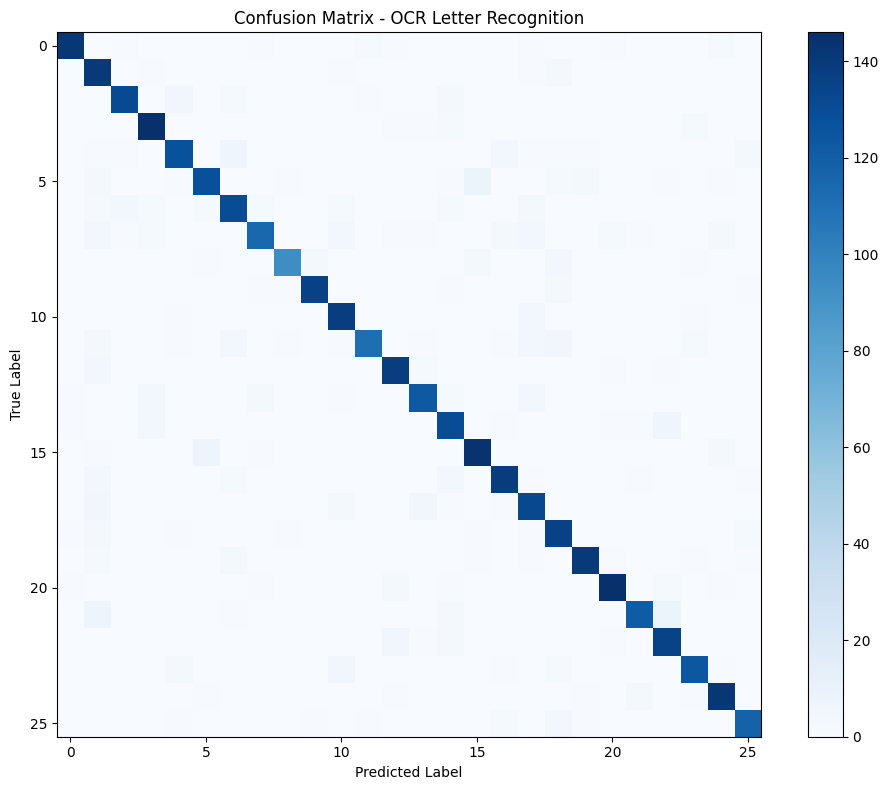

Sample predictions:
Actual: E, Predicted: E
Actual: Y, Predicted: Y
Actual: F, Predicted: F
Actual: E, Predicted: E
Actual: D, Predicted: D


In [4]:
model.eval()
with torch.no_grad():
    y_prob = torch.softmax(model(x_test_tensor.to(device)), dim=1).cpu().numpy()
    y_pred = np.argmax(y_prob, axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("Test accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))
print("\nComparison (Baseline vs Model):")
print(f"Accuracy: {baseline_accuracy:.4f} -> {accuracy:.4f}")

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - OCR Letter Recognition")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.tight_layout()
plt.show()

sample_indices = np.random.choice(len(x_test), size=5, replace=False)
print("Sample predictions:")
for idx in sample_indices:
    actual = label_encoder.inverse_transform([y_test[idx]])[0]
    predicted = label_encoder.inverse_transform([y_pred[idx]])[0]
    print(f"Actual: {actual}, Predicted: {predicted}")